In [2]:
import pandas as pd

# Dosyayı oku
df = pd.read_csv("iot_telemetry_ids.csv")

# İlk 5 satırı ekrana getir
df.head()

,ts,device,co,humidity,light,lpg,motion,smoke,temp,device_id,timestamp,label,attack_type
0,1594512094,b8:27:eb:bf:9d:51,0.004956,39.056407,False,0.007651,False,0.020411,29.579211,device_4,01-01-2025 00:00,1,DoS
1,1594512095,00:0f:00:70:91:0a,0.002840,75.050465,False,0.005114,False,0.013275,27.083662,device_3,01-01-2025 00:00,1,Spoofing
2,1594512098,b8:27:eb:bf:9d:51,0.004976,58.902531,False,0.007673,False,0.020475,36.340364,device_2,01-01-2025 00:00,1,Replay
3,1594512100,1c:bf:ce:15:ec:4d,0.004403,76.800003,True,0.007023,False,0.018628,27.000000,device_2,01-01-2025 00:00,0,Normal
4,1594512102,b8:27:eb:bf:9d:51,0.004967,46.129886,False,0.007664,False,0.020448,31.636413,device_4,01-01-2025 00:00,1,Data Injection


In [3]:
# Verinin satır ve sütun sayısı
print(f"Toplam Satır: {df.shape[0]} | Toplam Sütun: {df.shape[1]}\n")

# Hangi sütun var, tipleri ne, boş hücre var mı?
df.info()

Toplam Satır: 405184 | Toplam Sütun: 13

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405184 entries, 0 to 405183
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ts           405184 non-null  int64  
 1   device       405184 non-null  object 
 2   co           405184 non-null  float64
 3   humidity     405184 non-null  float64
 4   light        405184 non-null  bool   
 5   lpg          405184 non-null  float64
 6   motion       405184 non-null  bool   
 7   smoke        405184 non-null  float64
 8   temp         405184 non-null  float64
 9   device_id    405184 non-null  object 
 10  timestamp    405184 non-null  object 
 11  label        405184 non-null  int64  
 12  attack_type  405184 non-null  object 
dtypes: bool(2), float64(5), int64(2), object(4)
memory usage: 34.8+ MB


In [4]:
# Hedef sütundaki (label / attack) sınıfların dağılımı
if 'label' in df.columns:
    print(df['label'].value_counts())
else:
    print("Sütun isimleri:", df.columns.tolist())

label
1    202592
0    202592
Name: count, dtype: int64


/tmp/ipykernel_543/2071586991.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])


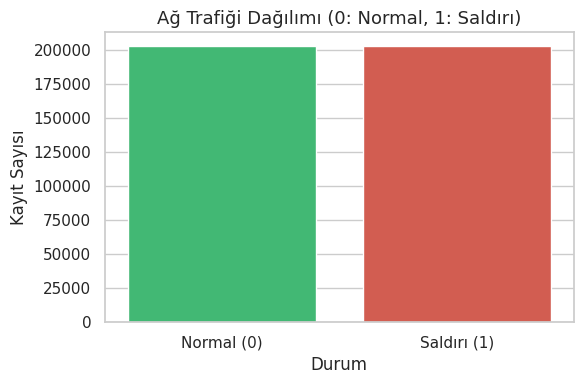

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin genel stilini ayarlayalım
sns.set_theme(style="whitegrid")

# 1. Saldırı ve Normal Verilerin Dağılım Grafiği
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])
plt.title("Ağ Trafiği Dağılımı (0: Normal, 1: Saldırı)", fontsize=13)
plt.xlabel("Durum")
plt.ylabel("Kayıt Sayısı")
plt.xticks([0, 1], ['Normal (0)', 'Saldırı (1)'])

# Grafiği bilgisayara kaydetmek için (GitHub README için çok işe yarayacak)
plt.tight_layout()
plt.savefig("trafik_dagilimi.png", dpi=300)
plt.show()

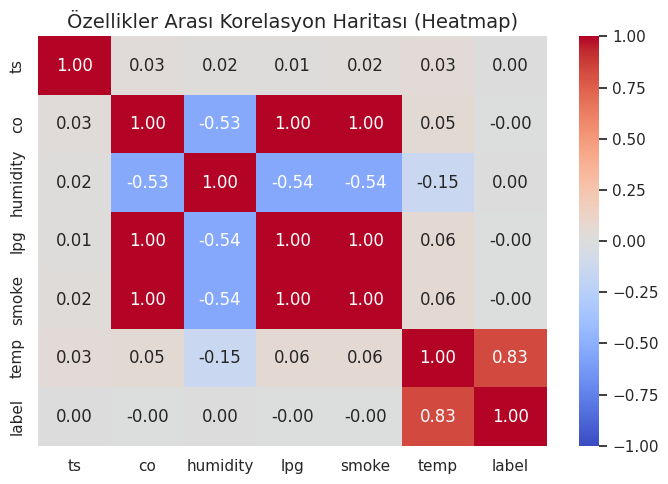

In [9]:
# Yalnızca sayısal sütunları seçelim
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Korelasyon matrisi hesaplayalım
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Özellikler Arası Korelasyon Haritası (Heatmap)", fontsize=14)

plt.tight_layout()
plt.savefig("korelasyon_haritasi.png", dpi=300)
plt.show()

In [10]:
# Hangi sütunlarımız var görelim
print("Mevcut Sütunlar:", df.columns.tolist())

# Hedef değişkenimiz (label)
y = df['label']

# X: label dışındaki diğer tüm sütunlar (sayısal olanları seçiyoruz)
X = df.drop(columns=['label'])

# Sadece sayısal özelliklerle çalışmak için filtreleyelim
X = X.select_dtypes(include=['float64', 'int64'])

print(f"\nModelin kullanacağı özellik (ipucu) sayısı: {X.shape[1]}")
print("Kullanılan özellikler:", X.columns.tolist())

Mevcut Sütunlar: ['ts', 'device', 'co', 'humidity', 'light', 'lpg', 'motion', 'smoke', 'temp', 'device_id', 'timestamp', 'label', 'attack_type']

Modelin kullanacağı özellik (ipucu) sayısı: 6
Kullanılan özellikler: ['ts', 'co', 'humidity', 'lpg', 'smoke', 'temp']


In [11]:
from sklearn.model_selection import train_test_split

# %80 Eğitim, %20 Test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Eğitim Verisi Boyutu: {X_train.shape[0]} satır")
print(f"Test Verisi Boyutu   : {X_test.shape[0]} satır")

Eğitim Verisi Boyutu: 324147 satır
Test Verisi Boyutu   : 81037 satır


In [12]:
from sklearn.ensemble import RandomForestClassifier

# 1. Modeli başlatalım (100 tane karar ağacından oluşan bir orman)
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Modeli eğitelim (Öğrenme aşaması)
# Modele eğitim sorularını (X_train) ve cevaplarını (y_train) veriyoruz
model.fit(X_train, y_train)

print("Tebrikler! Model eğitimi başarıyla tamamlandı.")

Tebrikler! Model eğitimi başarıyla tamamlandı.


In [13]:
# Model daha önce hiç görmediği X_test sorularına bakarak tahmin üretiyor
tahminler = model.predict(X_test)

# İlk 10 tahmini ve gerçek cevapları yan yana görelim
karsilastirma = pd.DataFrame({
    'Modelin Tahmini': tahminler[:10],
    'Gerçek Durum': y_test.iloc[:10].values
})
print(karsilastirma)

   Modelin Tahmini  Gerçek Durum
0                1             1
1                0             0
2                1             1
3                1             1
4                1             1
5                1             1
6                1             1
7                0             0
8                1             1
9                0             0


=== MODEL PERFORMANS KARNESİ ===
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     40519
 Saldırı (1)       1.00      1.00      1.00     40518

    accuracy                           1.00     81037
   macro avg       1.00      1.00      1.00     81037
weighted avg       1.00      1.00      1.00     81037



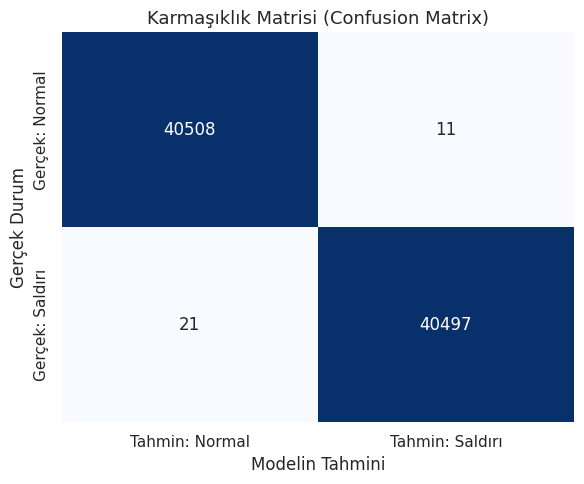

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Genel Karne (Rapor)
print("=== MODEL PERFORMANS KARNESİ ===")
print(classification_report(y_test, tahminler, target_names=['Normal (0)', 'Saldırı (1)']))

# 2. Karmaşıklık Matrisi (Confusion Matrix) Grafiği
cm = confusion_matrix(y_test, tahminler)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tahmin: Normal', 'Tahmin: Saldırı'],
            yticklabels=['Gerçek: Normal', 'Gerçek: Saldırı'])
plt.title("Karmaşıklık Matrisi (Confusion Matrix)", fontsize=13)
plt.ylabel("Gerçek Durum")
plt.xlabel("Modelin Tahmini")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

/tmp/ipykernel_543/1406878649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=onem_dereceleri[sirali_indeksler], y=ozellik_adlari[sirali_indeksler], palette='viridis')


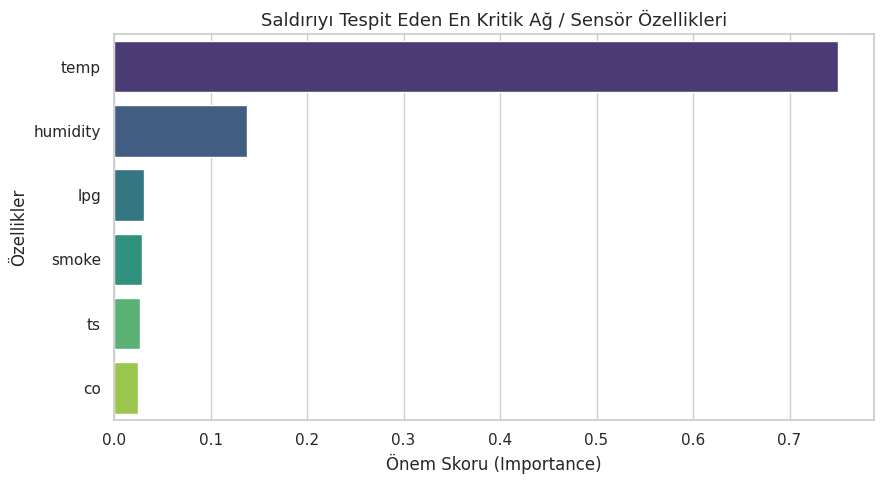

In [15]:
import numpy as np

# Modelin hangi özelliğe ne kadar önem verdiğini alalım
onem_dereceleri = model.feature_importances_
ozellik_adlari = X.columns

# Görselleştirelim
plt.figure(figsize=(9, 5))
sirali_indeksler = np.argsort(onem_dereceleri)[::-1]

sns.barplot(x=onem_dereceleri[sirali_indeksler], y=ozellik_adlari[sirali_indeksler], palette='viridis')
plt.title("Saldırıyı Tespit Eden En Kritik Ağ / Sensör Özellikleri", fontsize=13)
plt.xlabel("Önem Skoru (Importance)")
plt.ylabel("Özellikler")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()